# EDA: feature by feature

For every feature, three questions:
1. **How many values are missing?** Is the fraud rate different when the value is missing?
2. **Which values or groups have more frauds?** (grey = purchases, red = % of frauds, dashed line = average)
3. **In one sentence: is this feature useful?** → written in the *Finding* cell under each chart.

Three types of feature, one function each:
- **numbers** (the double makes sense: amount, days, counts) → `numeric(train, col)`
- **codes / categories** (a label, like a postal code: card, addr, email, M) → `category(train, col)`

Only months 0–3: the last months are kept hidden for the final test of the model.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

BLUE = "#A7C7E7"     # pastel blue: purchases
PINK = "#F4A7B9"     # pastel pink: frauds
LINE = "#6B6B6B"     # dark grey: average line

def missing(df, col):
    m = df[col].isna()
    print(f"{col}: missing {100 * m.mean():.1f}% of the rows")
    if 0 < m.sum() < len(df):
        print(f"  fraud rate WITH a value:    {100 * df.loc[~m, 'isFraud'].mean():.2f}%")
        print(f"  fraud rate WITHOUT a value: {100 * df.loc[m, 'isFraud'].mean():.2f}%")

from pathlib import Path

def _plot(groups, overall_pct, title, save=None):
    """groups must have 'purchases' and 'fraud_pct' (already in %). save = file name for docs/images/."""
    fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    x = range(len(groups))
    top.bar(x, groups["purchases"], color=BLUE)
    top.set_ylabel("purchases")
    top.set_title(title)
    bottom.bar(x, groups["fraud_pct"], color=PINK)
    bottom.axhline(overall_pct, color=LINE, linestyle="--", label=f"average {overall_pct:.1f}%")
    bottom.set_ylabel("frauds (%)")
    bottom.legend(frameon=False)
    bottom.set_xticks(list(x), list(groups.index), rotation=45, ha="right")
    for ax in (top, bottom):
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    if save:
        Path("../docs/images").mkdir(parents=True, exist_ok=True)
        plt.savefig(f"../docs/images/{save}", dpi=120)
    plt.show()

def by_time(df, col, title, save=None):
    """Purchases and % of frauds for each value of a time column (month, hour, weekday), in order."""
    groups = _summary(df, df[col]).sort_index()
    _plot(groups, df["isFraud"].mean() * 100, title, save)
    return groups

def _summary(df, labels):
    """Purchases and % of frauds for each group."""
    groups = df.groupby(labels)["isFraud"].agg(purchases="size", fraud_pct="mean")
    groups["fraud_pct"] = groups["fraud_pct"] * 100          # to % (ONLY here)
    return groups

def numeric(df, col, n_groups=10):
    missing(df, col)
    g = pd.qcut(df[col], n_groups, duplicates="drop")
    names = {c: f"{c.left:,.0f}–{c.right:,.0f}" for c in g.cat.categories}   # "0–26" instead of "(0.19, 26.0]"
    labels = g.map(names).astype(str).where(df[col].notna(), "missing")
    groups = _summary(df, labels)
    order = list(names.values()) + ["missing"]
    groups = groups.reindex([o for o in order if o in groups.index])
    _plot(groups, df["isFraud"].mean() * 100, f"{col}: purchases and frauds per group")
    return groups

def category(df, col, top=15):
    missing(df, col)
    v = df[col].astype("object")
    frequent = v.value_counts().head(top).index
    labels = v.where(v.isin(frequent), "other").where(v.notna(), "missing").astype(str)
    groups = _summary(df, labels).sort_values("purchases", ascending=False)
    _plot(groups, df["isFraud"].mean() * 100, f"{col}: purchases and frauds per value")
    return groups

In [7]:

df = pd.read_csv("../data/raw/train_transaction.csv")

DAY, HOUR = 86400, 3600
df["day"] = df["TransactionDT"] // DAY
df["month"] = df["day"] // 30
df.loc[df["month"] == 6, "month"] = 5          # "month 6" = last 2 days, joined to month 5
df["hour"] = (df["TransactionDT"] // HOUR) % 24
df["weekday"] = df["day"] % 7
df = df.copy()

train = df[df["month"] <= 3].copy()           # EDA only on months 0-3
print(train.shape, f"fraud rate {train['isFraud'].mean() * 100:.2f}%")

/var/folders/b_/hffw9msn0878h2ccgmlcvwt40000gn/T/ipykernel_40993/2343021452.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["day"] = df["TransactionDT"] // DAY
/var/folders/b_/hffw9msn0878h2ccgmlcvwt40000gn/T/ipykernel_40993/2343021452.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["month"] = df["day"] // 30
/var/folders/b_/hffw9msn0878h2ccgmlcvwt40000gn/T/ipykernel_40993/2343021452.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

(410601, 398) fraud rate 3.51%


## 0. Time

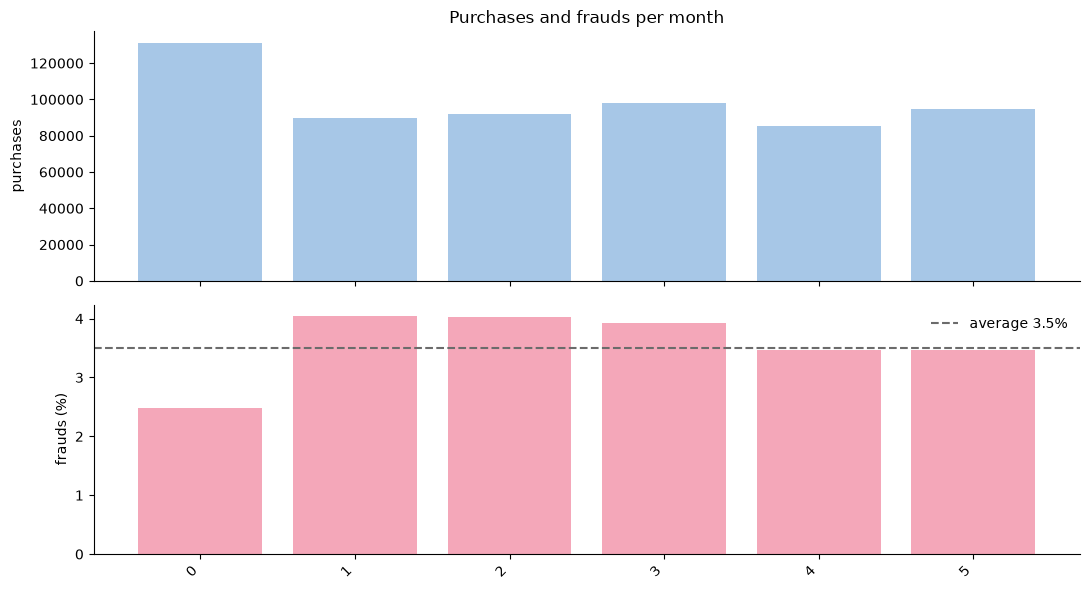

,purchases,fraud_pct
month,,
0,130968,2.476177
1,89838,4.037267
2,91768,4.031907
3,98027,3.926469
4,85303,3.472328
5,94636,3.468025


In [26]:
# month by month: all 6 months (only to see if the fraud rate changes over time)
by_time(df, "month", "Purchases and frauds per month", save="per_month.png")

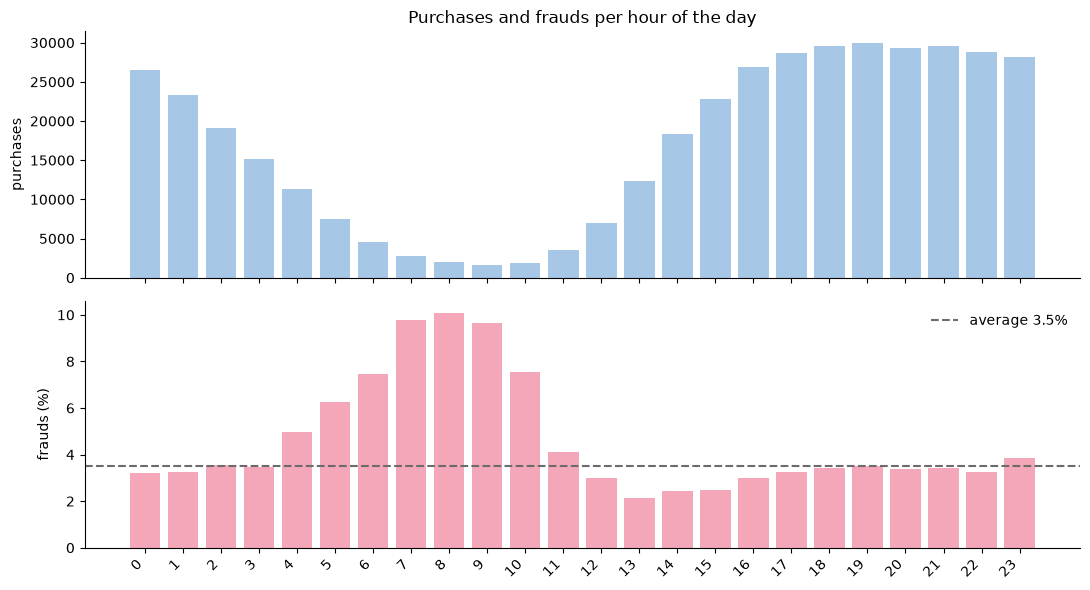

,purchases,fraud_pct
hour,,
0,26564,3.214877
1,23369,3.256451
2,19150,3.571802
3,15208,3.471857
4,11280,4.991135
5,7541,6.272378
6,4578,7.470511
7,2821,9.783765
8,1945,10.077121


In [27]:
by_time(train, "hour", "Purchases and frauds per hour of the day", save="per_hour.png")

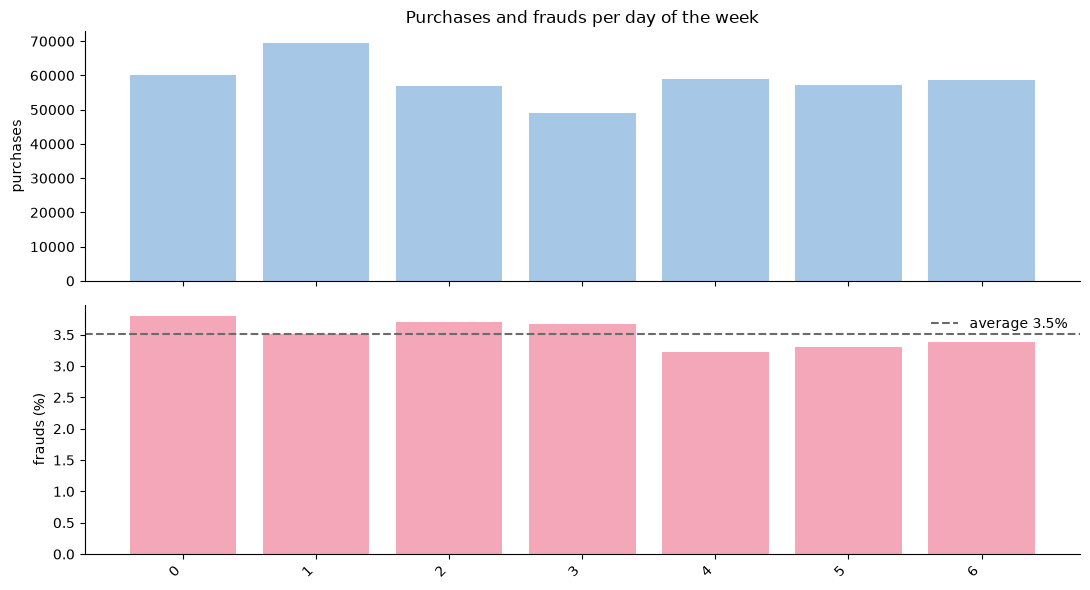

,purchases,fraud_pct
weekday,,
0,60270,3.792932
1,69421,3.516227
2,56973,3.710530
3,48937,3.665938
4,59080,3.224441
5,57121,3.303514
6,58799,3.387813


In [28]:
by_time(train, "weekday", "Purchases and frauds per day of the week", save="per_weekday.png")

## 1. TransactionAmt (amount)

Type: **numbers**

TransactionAmt: missing 0.0% of the rows


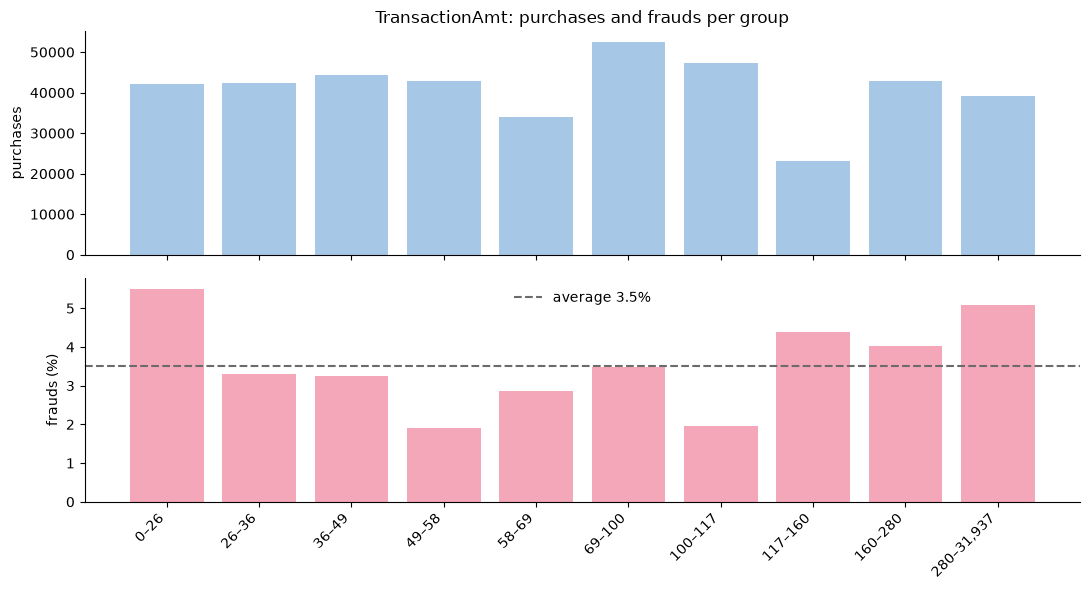

,purchases,fraud_pct
TransactionAmt,,
0–26,42164,5.497581
26–36,42309,3.292444
36–49,44386,3.242013
49–58,42766,1.905719
58–69,33923,2.865313
69–100,52500,3.472381
100–117,47277,1.954439
117–160,23180,4.378775
160–280,42948,4.023470


In [8]:
numeric(train, "TransactionAmt")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

## 2. ProductCD (type of product)

Type: **codes, few values**

ProductCD: missing 0.0% of the rows


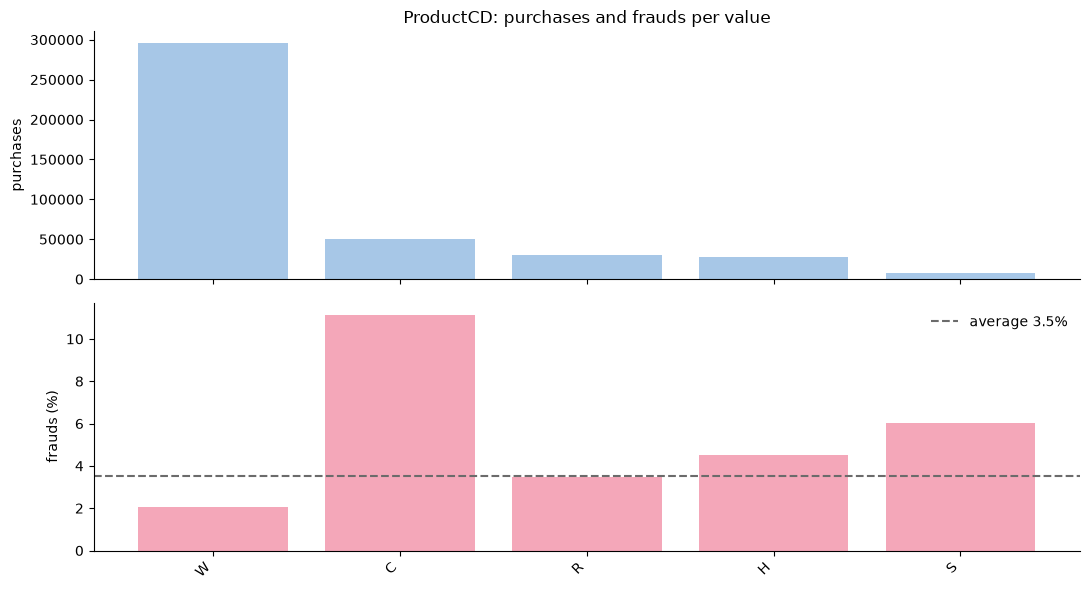

,purchases,fraud_pct
ProductCD,,
W,295680,2.074878
C,49665,11.150710
R,30037,3.475713
H,28048,4.524387
S,7171,6.038209


In [9]:
category(train, "ProductCD")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

## 3. card1 – card6 (the card)

Type: **card4, card6: few values · card1, card2, card3, card5: many values**

card4: missing 0.2% of the rows
  fraud rate WITH a value:    3.51%
  fraud rate WITHOUT a value: 3.14%


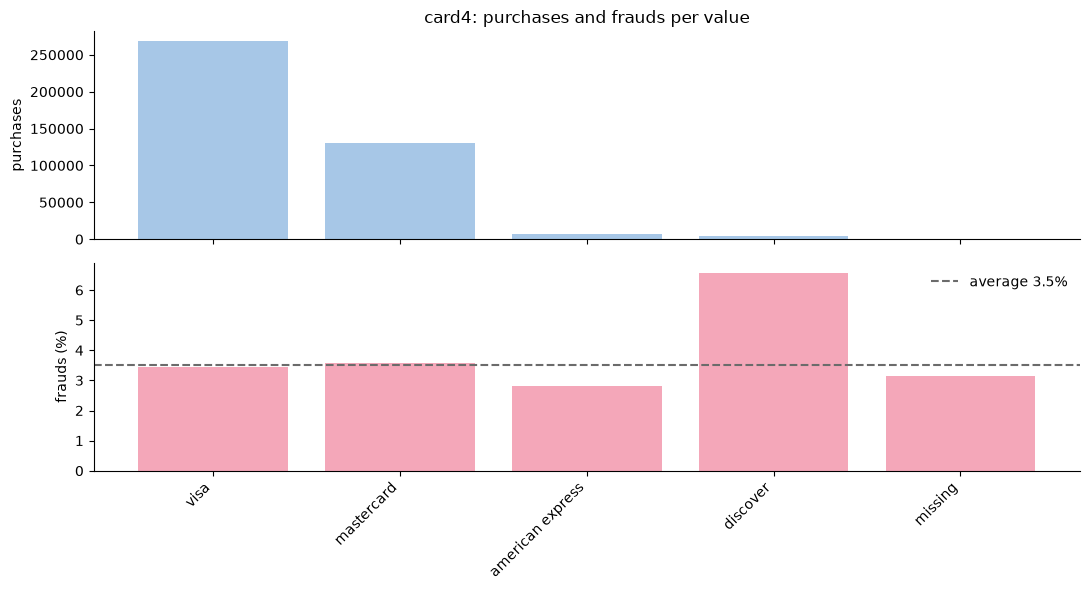

,purchases,fraud_pct
card4,,
visa,268406,3.449997
mastercard,129895,3.565957
american express,6726,2.809991
discover,4745,6.575342
missing,829,3.136309


In [10]:
category(train, "card4")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

card6: missing 0.2% of the rows
  fraud rate WITH a value:    3.51%
  fraud rate WITHOUT a value: 2.91%


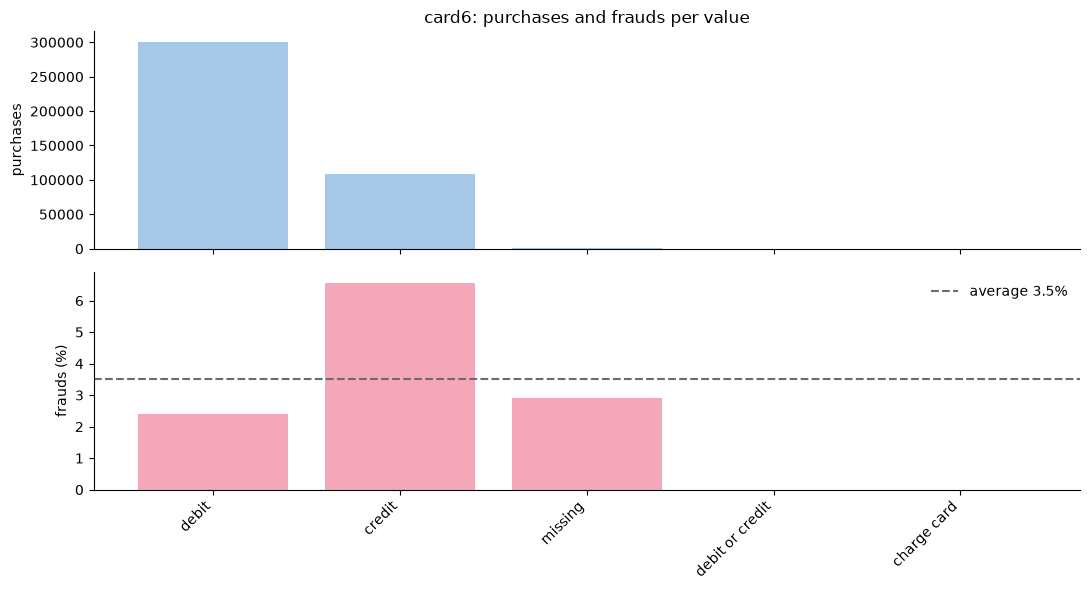

,purchases,fraud_pct
card6,,
debit,300865,2.407392
credit,108866,6.569544
missing,826,2.905569
debit or credit,29,0.000000
charge card,15,0.000000


In [11]:
category(train, "card6")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

card1: missing 0.0% of the rows


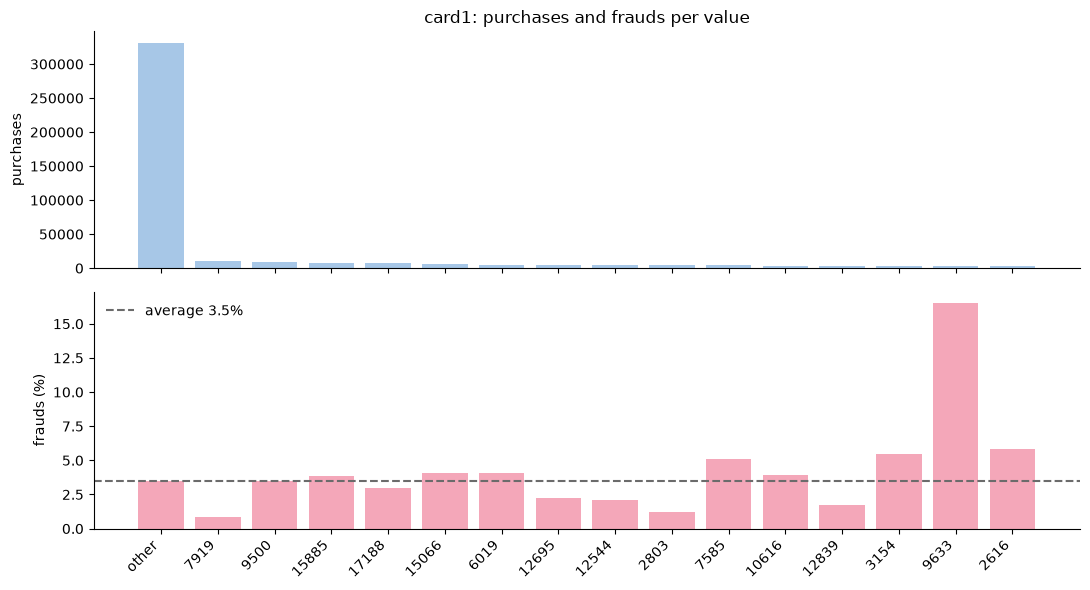

,purchases,fraud_pct
card1,,
other,331509,3.477432
7919,9878,0.860498
9500,9614,3.453297
15885,7487,3.833311
17188,7060,2.988669
15066,5439,4.063247
6019,5169,4.043335
12695,4741,2.214723
12544,4601,2.064769


In [12]:
category(train, "card1")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

card2: missing 1.6% of the rows
  fraud rate WITH a value:    3.47%
  fraud rate WITHOUT a value: 5.89%


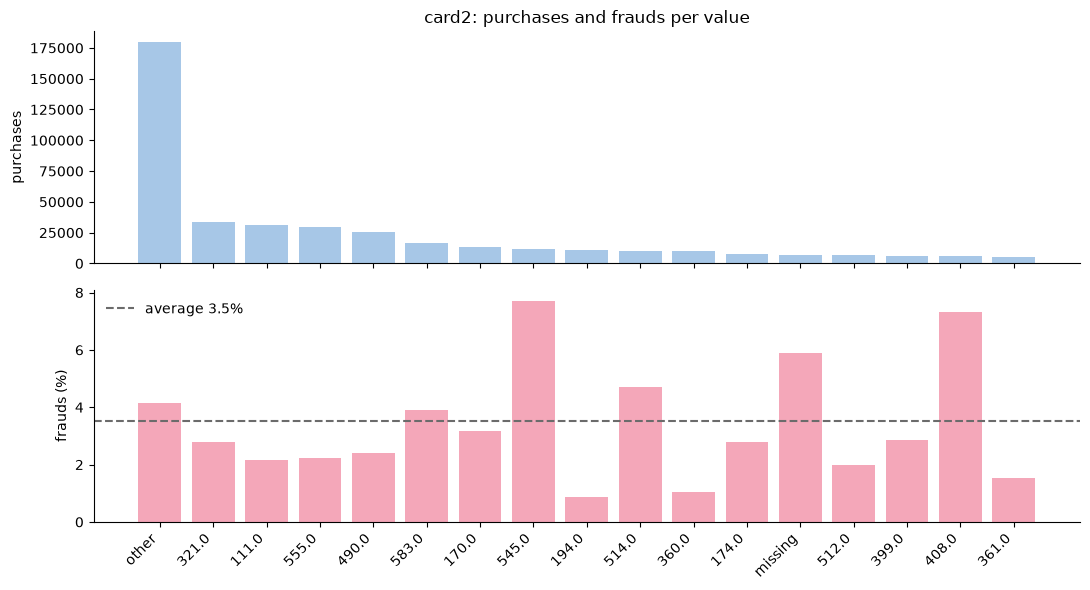

,purchases,fraud_pct
card2,,
other,179492,4.157845
321.0,33427,2.773207
111.0,31255,2.159654
555.0,29474,2.242655
490.0,25853,2.394306
583.0,16395,3.903629
170.0,13014,3.188874
545.0,11816,7.709885
194.0,11270,0.887311


In [13]:
category(train, "card2")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

card3: missing 0.2% of the rows
  fraud rate WITH a value:    3.51%
  fraud rate WITHOUT a value: 2.92%


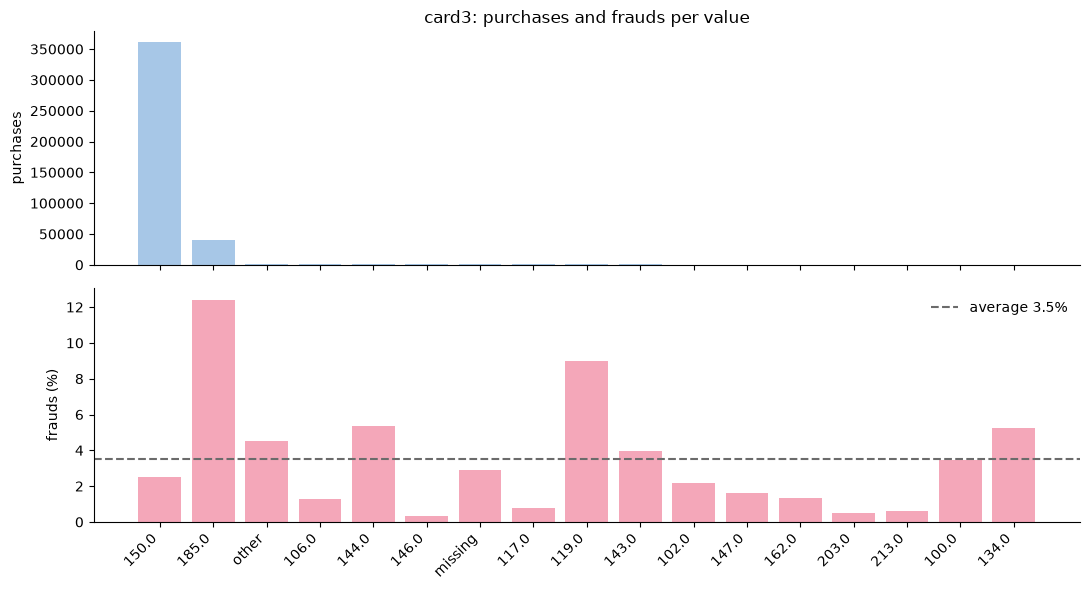

,purchases,fraud_pct
card3,,
150.0,360717,2.507783
185.0,40913,12.419036
other,1863,4.508857
106.0,1111,1.260126
144.0,986,5.375254
146.0,889,0.337458
missing,821,2.923264
117.0,646,0.773994
119.0,644,9.006211


In [14]:
category(train, "card3")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

card5: missing 0.7% of the rows
  fraud rate WITH a value:    3.50%
  fraud rate WITHOUT a value: 5.03%


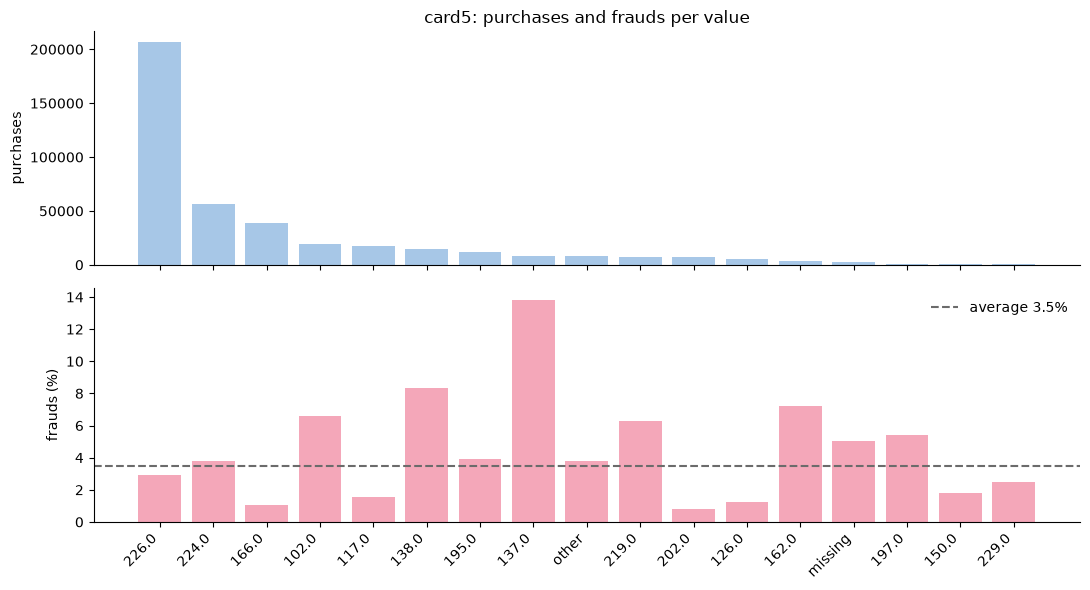

,purchases,fraud_pct
card5,,
226.0,206320,2.945909
224.0,56297,3.811926
166.0,38726,1.025151
102.0,19691,6.607079
117.0,17337,1.563131
138.0,14344,8.317066
195.0,11880,3.922559
137.0,8497,13.840179
other,8310,3.790614


In [15]:
category(train, "card5")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

## 4. addr1, addr2 (billing region and country), dist1, dist2 (distances)

Type: **addr: codes · dist: numbers**

addr1: missing 11.5% of the rows
  fraud rate WITH a value:    2.51%
  fraud rate WITHOUT a value: 11.22%


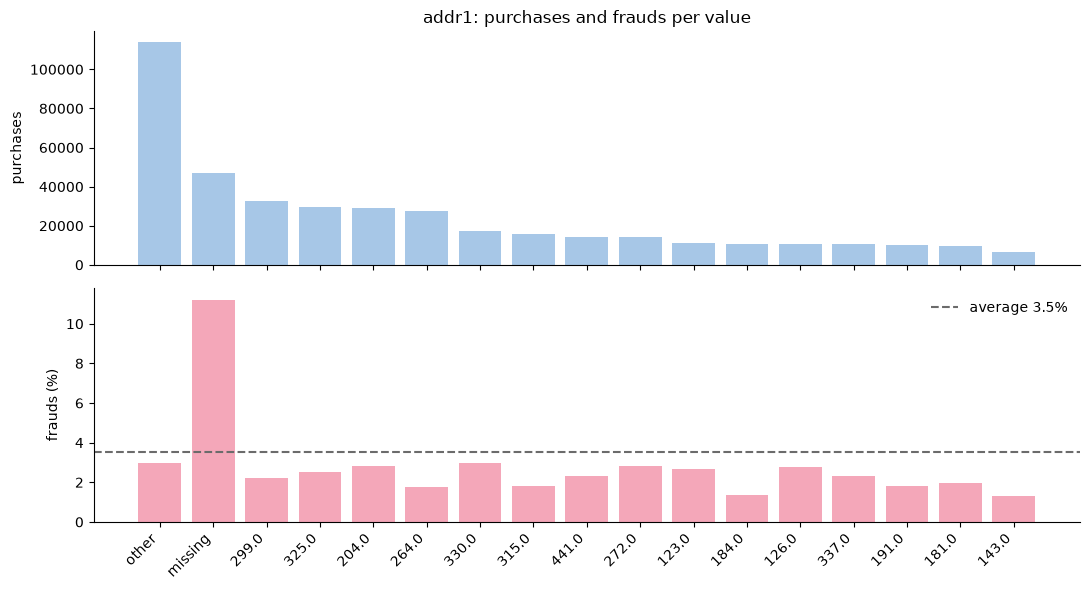

,purchases,fraud_pct
addr1,,
other,113761,2.972020
missing,47184,11.219905
299.0,32713,2.204017
325.0,29495,2.502119
204.0,28984,2.836047
264.0,27507,1.788636
330.0,17228,2.977711
315.0,15842,1.817952
441.0,14312,2.312745


In [16]:
category(train, "addr1")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

addr2: missing 11.5% of the rows
  fraud rate WITH a value:    2.51%
  fraud rate WITHOUT a value: 11.22%


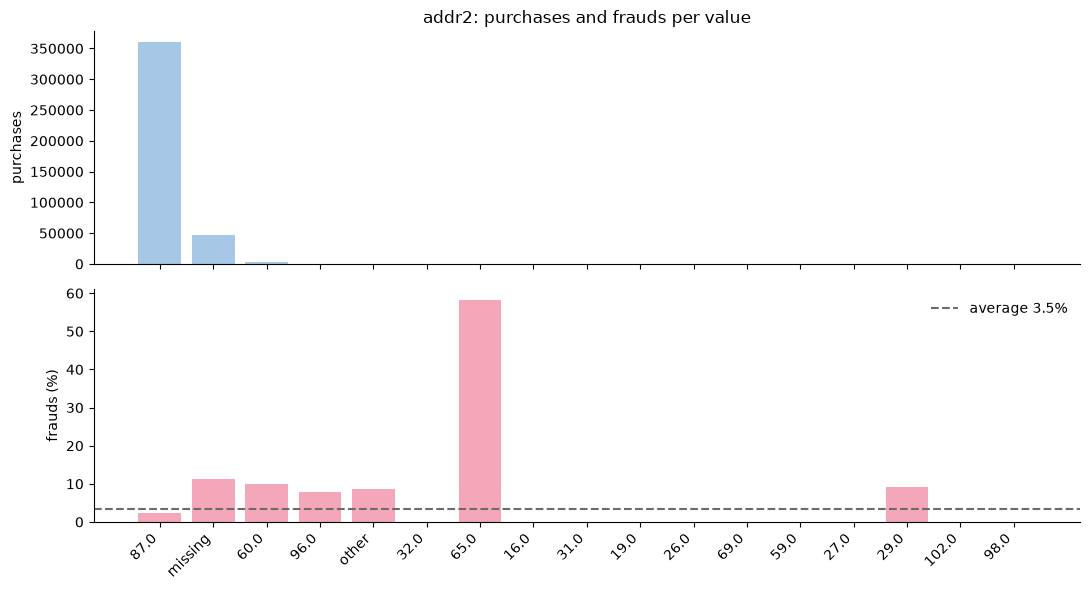

,purchases,fraud_pct
addr2,,
87.0,359809,2.438516
missing,47184,11.219905
60.0,2567,9.855863
96.0,516,7.751938
other,160,8.750000
32.0,77,0.000000
65.0,74,58.108108
16.0,47,0.000000
31.0,44,0.000000


In [17]:
category(train, "addr2")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

dist1: missing 61.9% of the rows
  fraud rate WITH a value:    2.01%
  fraud rate WITHOUT a value: 4.44%


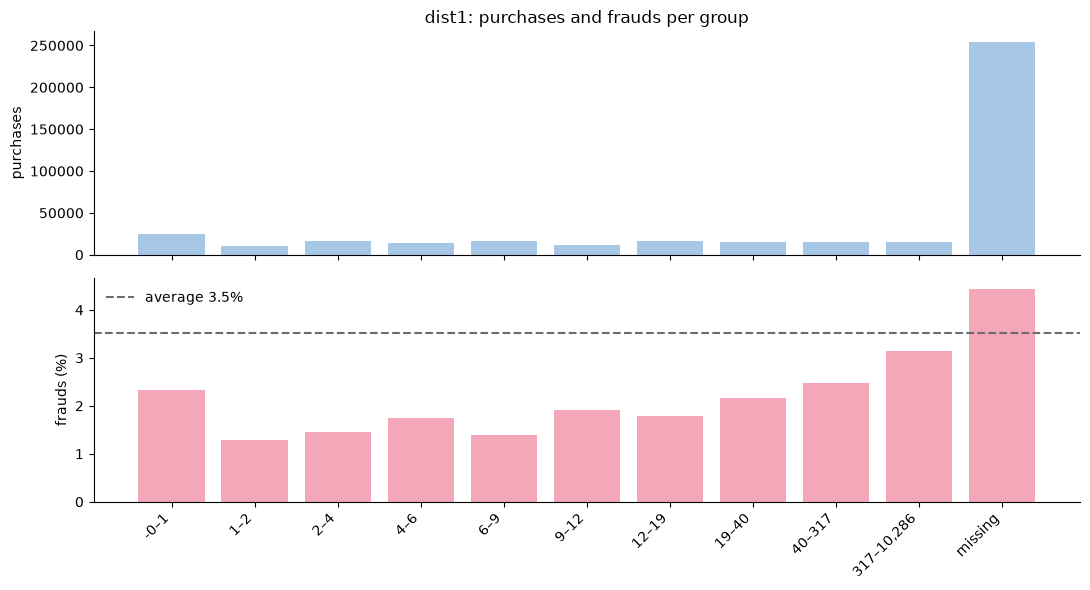

,purchases,fraud_pct
dist1,,
-0–1,24558,2.321036
1–2,10719,1.278104
2–4,16814,1.463066
4–6,14192,1.754510
6–9,16287,1.393750
9–12,11345,1.921551
12–19,15901,1.792340
19–40,15609,2.171824
40–317,15376,2.484391


In [18]:
numeric(train, "dist1")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

dist2: missing 92.9% of the rows
  fraud rate WITH a value:    9.20%
  fraud rate WITHOUT a value: 3.08%


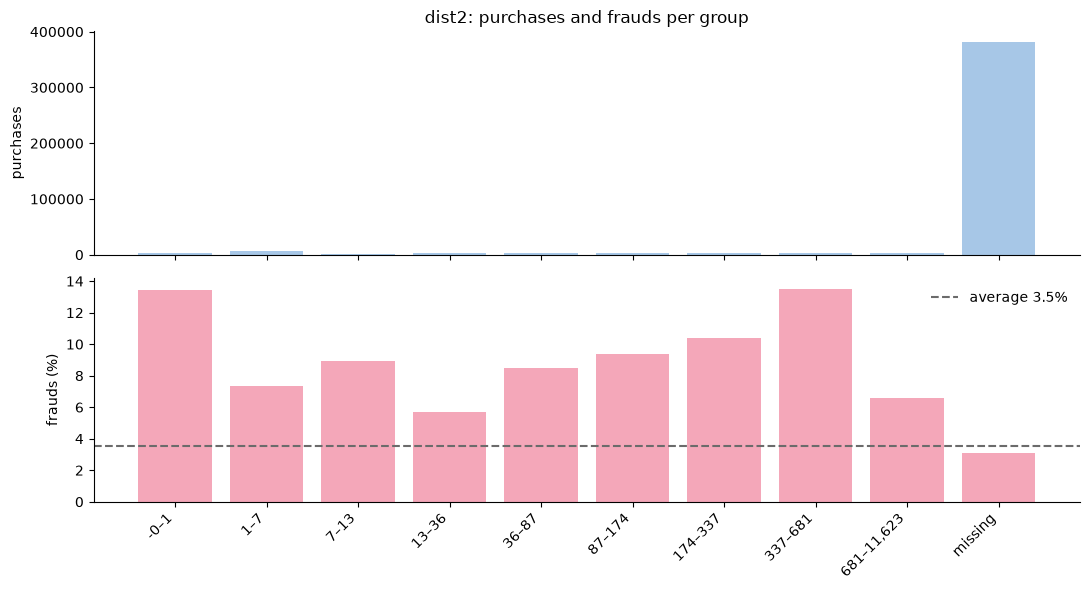

,purchases,fraud_pct
dist2,,
-0–1,3595,13.435327
1–7,6678,7.367475
7–13,1562,8.962868
13–36,2735,5.703839
36–87,2866,8.478716
87–174,2889,9.380408
174–337,2911,10.374442
337–681,2896,13.501381
"681–11,623",2904,6.611570


In [19]:
numeric(train, "dist2")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

## 5. P_emaildomain, R_emaildomain (email of buyer and receiver)

Type: **codes, many values**

P_emaildomain: missing 15.6% of the rows
  fraud rate WITH a value:    3.61%
  fraud rate WITHOUT a value: 3.00%


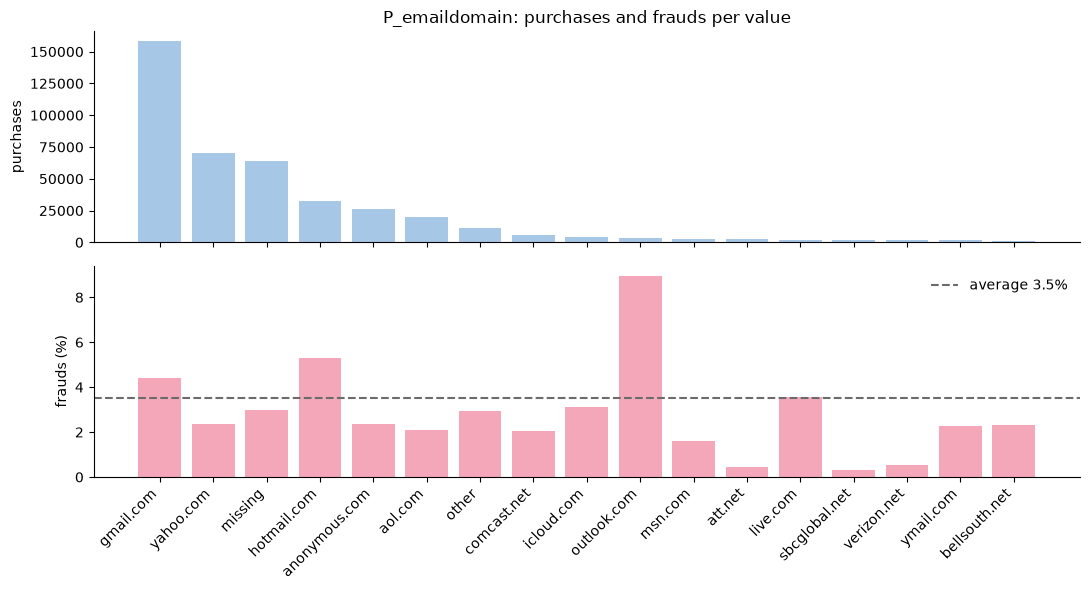

,purchases,fraud_pct
P_emaildomain,,
gmail.com,158056,4.400972
yahoo.com,69933,2.356541
missing,63889,3.002082
hotmail.com,32587,5.311934
anonymous.com,26589,2.365640
aol.com,19689,2.087460
other,11322,2.958841
comcast.net,5711,2.066188
icloud.com,4292,3.098788


In [20]:
category(train, "P_emaildomain")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

R_emaildomain: missing 75.0% of the rows
  fraud rate WITH a value:    7.67%
  fraud rate WITHOUT a value: 2.13%


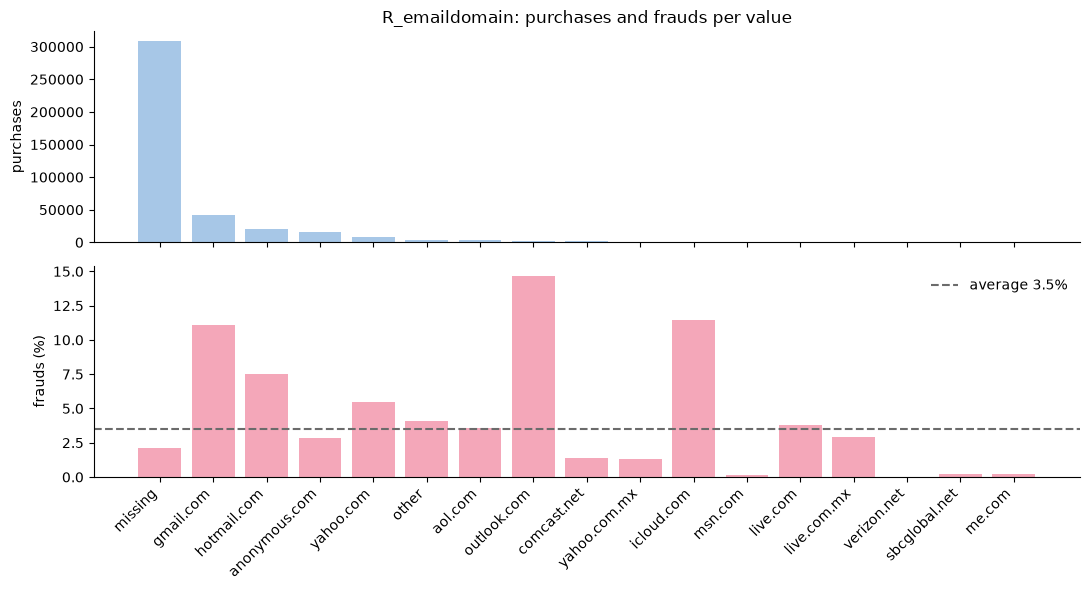

,purchases,fraud_pct
R_emaildomain,,
missing,308095,2.126617
gmail.com,42410,11.079934
hotmail.com,20370,7.540501
anonymous.com,15736,2.878749
yahoo.com,8250,5.503030
other,3997,4.053040
aol.com,3055,3.567921
outlook.com,1760,14.659091
comcast.net,1506,1.394422


In [21]:
category(train, "R_emaildomain")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

## 6. C1 – C14 (counts)

Type: **numbers**

C1: missing 0.0% of the rows


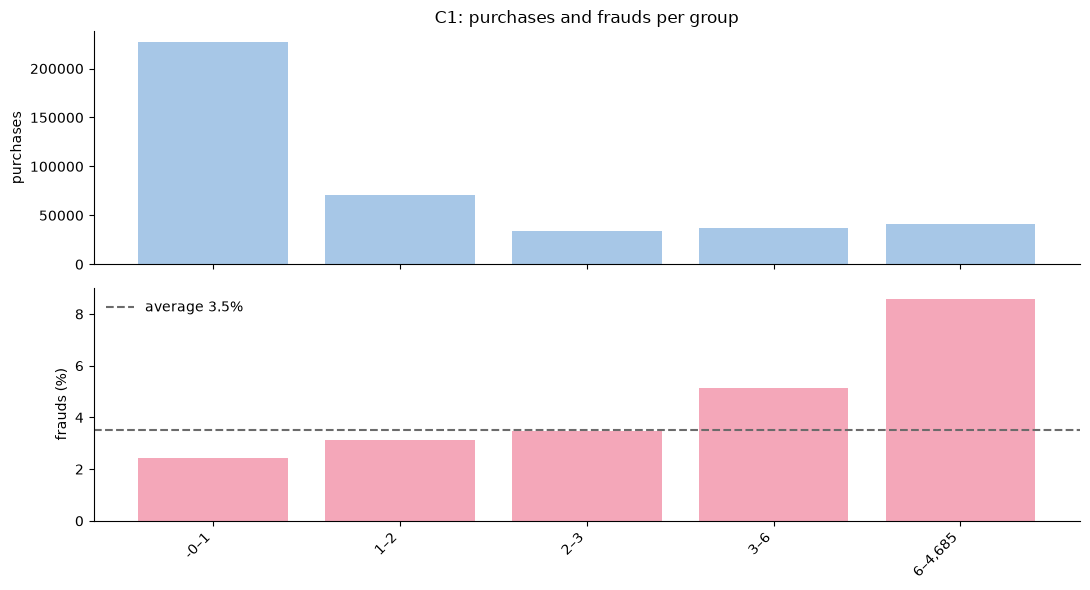

,purchases,fraud_pct
C1,,
-0–1,226679,2.449278
1–2,71100,3.144866
2–3,34508,3.462965
3–6,37374,5.145288
"6–4,685",40940,8.580850


In [22]:
numeric(train, "C1")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

_Repeat for the other columns of the group (copy the cell and change the name)._

## 7. D1 – D15 (days passed)

Type: **numbers**

D1: missing 0.1% of the rows
  fraud rate WITH a value:    3.51%
  fraud rate WITHOUT a value: 0.37%


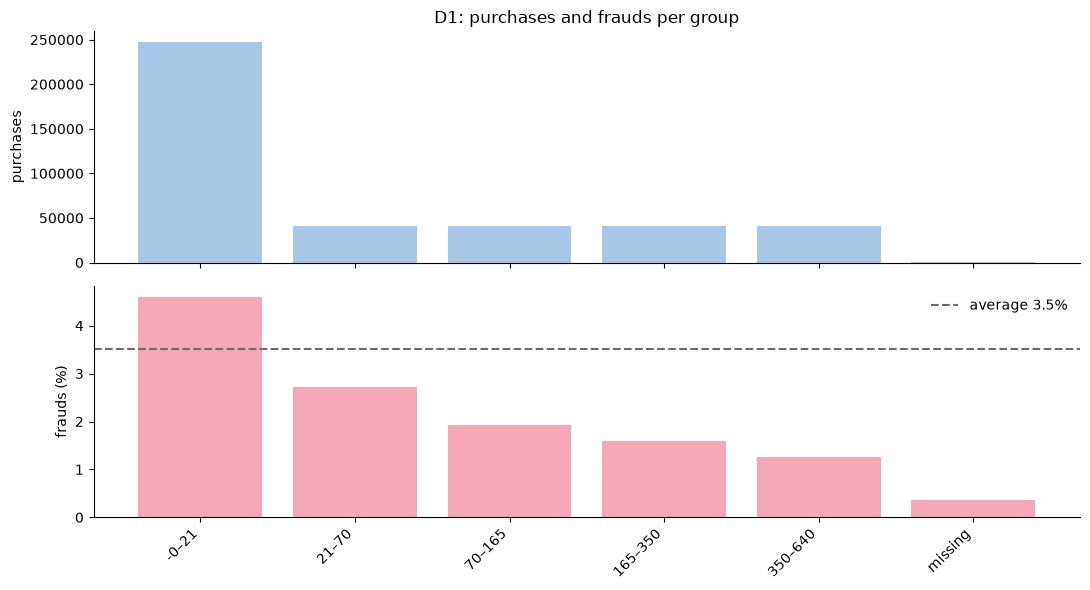

,purchases,fraud_pct
D1,,
-0–21,246990,4.595733
21–70,40942,2.720922
70–165,40458,1.935340
165–350,40974,1.586372
350–640,40964,1.269407
missing,273,0.366300


In [24]:
numeric(train, "D1")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

_Repeat for the other columns of the group (copy the cell and change the name)._

## 8. M1 – M9 (matches, T/F)

Type: **codes, few values**

M1: missing 54.0% of the rows
  fraud rate WITH a value:    2.01%
  fraud rate WITHOUT a value: 4.79%


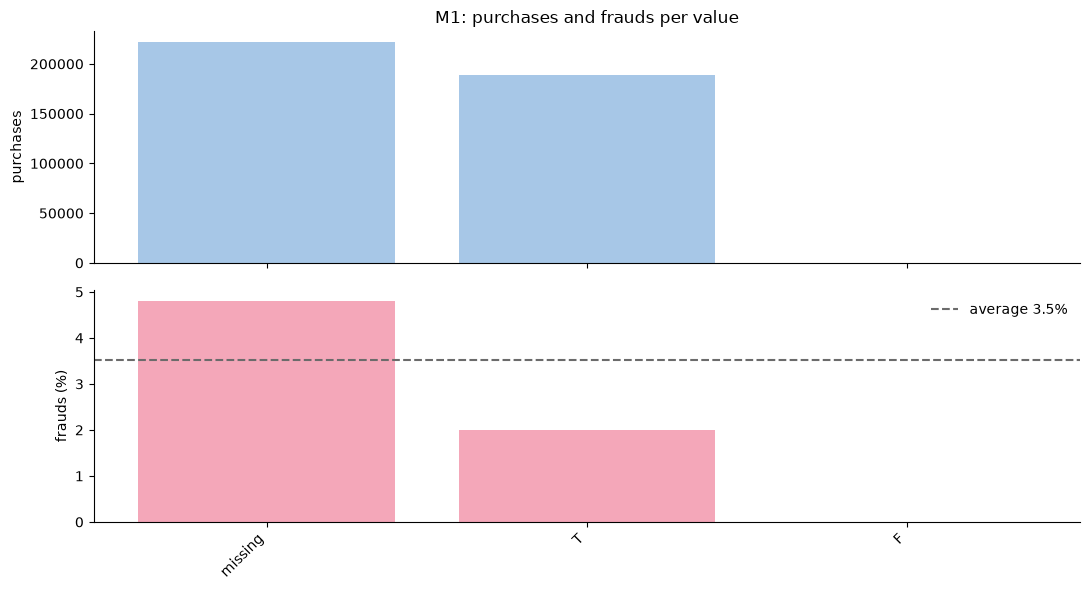

,purchases,fraud_pct
M1,,
missing,221639,4.79338
T,188946,2.00851
F,16,0.00000


In [23]:
category(train, "M1")

**Finding:** _write here, in one sentence, what the chart says and if the feature is useful._

_Repeat for the other columns of the group (copy the cell and change the name)._

## 9. V1 – V339

339 columns: not one chart each. We will group them first (columns that are missing on the same rows),
then look at a few per group. Method to be decided when we get here.

## 10. Identity table (device, browser)

To be joined with `train_transaction` on `TransactionID`. Later.

## Summary

| feature | useful? | what we do with it (clean / missing flag / new feature / rule) |
|---|---|---|
| TransactionAmt | | |
| ProductCD | | |